# Backtester Core Engine

**Owner:** James  
**Version:** 2.0 (Feb 13, 2026)  

Core backtesting engine for evaluating sports betting strategies.  
All logic is imported from `src/cuic_quant/backtest/backtester_backend.py`.  
See `docs/reference/strategy-interface.md` for the strategy function contract.

## Output Format

| Column | Type | Description |
|--------|------|-------------|
| timestamp | datetime | When trade happened |
| game | str | "Home vs Away" |
| action | str | 'BUY_HOME' or 'BUY_AWAY' |
| bet_size | float | Dollars bet |
| odds | float | Decimal odds used |
| outcome | str | 'WIN' or 'LOSS' |
| pnl | float | Profit/loss for this trade |
| cumulative_pnl | float | Running total P&L |
| bankroll | float | Current bankroll after trade |

## Assumptions & Limitations

- **Odds at face value** -- no slippage, liquidity constraints, or market impact modeling. Bets are assumed to be filled at the quoted odds.
- **Synthetic data** -- the default dataset (`dummy_backtest_input.csv`) is generated test data, not real market data.
- **Single bet per game** -- no parlays, accumulators, or multi-leg bets.
- **No CLV (Closing Line Value)** -- our data has a single odds snapshot per game. CLV calculation requires closing odds data (future enhancement).
- **Transaction costs optional** -- costs default to 0. Use `cost_pct` and `cost_flat` parameters in `backtest()` to model bookmaker vig and fees.
- **Kelly sizing optional** -- use `position_sizing="kelly"` to enable Kelly Criterion bet sizing based on strategy confidence values.

## Architecture: End-to-End Pipeline

The backtester follows a linear pipeline. Each stage feeds the next, and the strategy function never sees the outcome column.

```
CSV / Database ──> load_backtest_data() ──> DataFrame (N games)
                                                │
                                                ▼
                  Strategy Function  <── row (no home_win) <── backtest() loop
                                                │
                                                ▼
                                        Results DataFrame (9 columns)
                                                │
                    ┌───────────────────────────┼───────────────────────────┐
                    ▼                           ▼                           ▼
        validate_backtest_results()   display_extended_metrics()   plot_performance()
        (12 checks: schema,           (12 metrics: Sharpe,         (2x2 dashboard:
         math, data leakage)           Sortino, drawdown, etc.)     equity, drawdown,
                                                                    PnL dist, outcomes)
```

**Key invariant:** The `backtest()` loop strips `home_win` from each row before passing it to the strategy function. This prevents data leakage -- strategies cannot cheat by looking at the outcome. The validation suite verifies this with a dedicated "spy strategy" test.

In [ ]:
import sys
from pathlib import Path

# Ensure src/ is importable when running from tools/ directory
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cuic_quant.backtest import (
    load_backtest_data,
    backtest,
    always_bet_home,
    kelly_bet_home_demo,
    validate_backtest_results,
    display_extended_metrics,
    plot_performance,
)

## Configuration

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
DUMMY_CSV = DATA_DIR / "dummy_backtest_input.csv"

## Load Data

In [3]:
data = load_backtest_data("2026-01-01", "2026-01-31", csv_path=DUMMY_CSV)
print(f"Games loaded: {len(data)}")
data.head()

Loaded 25 rows from dummy_backtest_input.csv.
Games loaded: 25


,timestamp,game,home_team,away_team,home_odds,away_odds,home_win
0,2026-01-01,Lakers vs Celtics,Lakers,Celtics,1.95,2.05,1
1,2026-01-02,Warriors vs Heat,Warriors,Heat,1.80,2.20,1
2,2026-01-03,Bucks vs Nets,Bucks,Nets,1.65,2.45,1
3,2026-01-04,Nuggets vs Suns,Nuggets,Suns,2.10,1.85,0
4,2026-01-05,76ers vs Knicks,76ers,Knicks,1.90,2.00,1


## Strategy

Using the built-in `kelly_bet_home` strategy with **Kelly Criterion position sizing**. This strategy estimates win probability from implied odds (+ 5% edge) and Kelly sizes each bet as a fraction of the current bankroll.

To use your own strategy, replace the assignment below:

```python
def my_strategy(row, context=None):
    return {"action": "BUY_HOME", "confidence": 0.8, "size": 50.0}

strategy = my_strategy
```

For flat-bet sizing (ignoring confidence), omit `position_sizing` from the `backtest()` call.

See `docs/reference/strategy-interface.md` for the full contract.

---

### Kelly Criterion — How the Math Works

The Kelly Criterion calculates the optimal fraction of your bankroll to bet, maximizing long-term growth while avoiding ruin.

**Formula:**

$$f^* = \frac{bp - q}{b}$$

| Variable | Meaning | Example (odds = 1.95) |
|----------|---------|----------------------|
| $f^*$ | Fraction of bankroll to bet | 0.1026 (≈10.3%) |
| $b$ | Net odds = `decimal_odds - 1` | 1.95 - 1 = 0.95 |
| $p$ | Your estimated win probability | 0.5628 (implied + 5% edge) |
| $q$ | Loss probability = `1 - p` | 0.4372 |

**Worked example** (Lakers vs Celtics, odds = 1.95):

1. Implied probability: `1 / 1.95 = 0.5128`
2. Add 5% edge → confidence `p = 0.5628`
3. Net odds: `b = 1.95 - 1 = 0.95`
4. Full Kelly: `f* = (0.95 × 0.5628 - 0.4372) / 0.95 = 0.1026` → bet 10.3% of bankroll
5. Half Kelly (×0.5): `0.1026 × 0.5 = 0.0513` → bet 5.1% of bankroll
6. On $10,000 bankroll: `$10,000 × 0.0513 = $513.16` ← matches first trade in output

### Tweaking the Calculation

There are **three places** you can adjust Kelly sizing:

| What to tweak | Where | How |
|---------------|-------|-----|
| **Kelly fraction** (aggressiveness) | `backtest()` call in this notebook | Change `kelly_fraction=0.5` → `0.25` (quarter-Kelly, safer) or `1.0` (full Kelly, aggressive) |
| **Confidence / win probability** | Your strategy function's `confidence` return value | Higher confidence → bigger bets. The `kelly_bet_home` strategy uses `min(1/odds + 0.05, 0.95)` — change `0.05` to adjust the assumed edge |
| **Max bet cap** | `calculate_kelly_fraction()` in `src/cuic_quant/strategies/kelly_criterion.py:29` | `max_fraction=0.25` caps any single bet at 25% of bankroll — lower it for safety |

**Quick reference for `kelly_fraction` values:**

| Value | Name | Risk Profile | Use When |
|-------|------|-------------|----------|
| 0.25 | Quarter Kelly | Very conservative | Uncertain about edge estimates |
| 0.50 | Half Kelly | Moderate (default) | Good balance of growth vs. drawdown |
| 0.75 | Three-quarter Kelly | Aggressive | High confidence in edge estimates |
| 1.00 | Full Kelly | Maximum growth | Perfect edge estimates (unrealistic) |

> **Why half Kelly?** Full Kelly maximizes long-term growth but produces large drawdowns (~50% of bankroll). Half Kelly sacrifices ~25% of growth rate but cuts variance in half — widely considered the practical sweet spot.

### Worked Examples: Strategy Patterns

Below are three example strategies showing common patterns. Each returns the required dict with `action`, `confidence`, and `size`.

---

**Example 1: Odds-Based Filtering**

Only bet when home odds fall in a "value" range. This demonstrates selective betting based on odds thresholds.

```python
def odds_filter_strategy(row, context=None):
    """Only bet on home team when odds suggest value (1.5-2.5 range)."""
    if 1.5 <= row["home_odds"] <= 2.5:
        return {"action": "BUY_HOME", "confidence": 1/row["home_odds"], "size": 100.0}
    return {"action": "SKIP", "confidence": 0, "size": 0}
```

---

**Example 2: Bankroll-Percentage Sizing via Context**

Bet 2% of current bankroll on the favourite. The `context` dict (passed by `backtest()`) contains `bankroll`, `trade_number`, and `results_so_far`.

```python
def percentage_bankroll(row, context=None):
    """Bet 2% of current bankroll on favourite."""
    if context is None:
        return {"action": "SKIP", "confidence": 0, "size": 0}
    bet_size = context["bankroll"] * 0.02
    if row["home_odds"] < row["away_odds"]:
        return {"action": "BUY_HOME", "confidence": 1/row["home_odds"], "size": bet_size}
    return {"action": "BUY_AWAY", "confidence": 1/row["away_odds"], "size": bet_size}
```

---

**Example 3: Selective Betting (Low-Vig Filter)**

Only bet when the bookmaker's total implied probability (vig) is low, suggesting efficient odds. Most games are skipped.

```python
def selective_strategy(row, context=None):
    """Only bet when there is a large odds discrepancy (potential value)."""
    implied_home = 1 / row["home_odds"]
    implied_away = 1 / row["away_odds"]
    total_implied = implied_home + implied_away

    # Only bet when vig is low (total implied < 1.05)
    if total_implied > 1.05:
        return {"action": "SKIP", "confidence": 0, "size": 0}

    if implied_home > 0.55:
        return {"action": "BUY_HOME", "confidence": implied_home, "size": 100.0}
    return {"action": "SKIP", "confidence": 0, "size": 0}
```

> **Tip:** A good strategy skips most games. Betting on every game (like `always_bet_home`) is a baseline, not a goal.

In [ ]:
strategy = kelly_bet_home_demo

## Run Backtest

In [5]:
results = backtest(data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)
print(f"Total trades: {len(results)}")
results

Total trades: 25


,timestamp,game,action,bet_size,odds,outcome,pnl,cumulative_pnl,bankroll
0,2026-01-01,Lakers vs Celtics,BUY_HOME,256.58,1.95,WIN,243.75,243.75,10243.75
1,2026-01-02,Warriors vs Heat,BUY_HOME,288.11,1.80,WIN,230.49,474.24,10474.24
2,2026-01-03,Bucks vs Nets,BUY_HOME,332.36,1.65,WIN,216.03,690.27,10690.27
3,2026-01-04,Nuggets vs Suns,BUY_HOME,255.11,2.10,LOSS,-255.11,435.16,10435.16
4,2026-01-05,76ers vs Knicks,BUY_HOME,275.37,1.90,WIN,247.83,682.99,10682.99
5,2026-01-06,Celtics vs Heat,BUY_HOME,324.31,1.70,WIN,227.02,910.01,10910.01
6,2026-01-07,Lakers vs Warriors,BUY_HOME,254.96,2.15,LOSS,-254.96,655.05,10655.05
7,2026-01-08,Nets vs Bucks,BUY_HOME,228.32,2.40,LOSS,-228.32,426.73,10426.73
8,2026-01-09,Suns vs 76ers,BUY_HOME,267.53,1.95,WIN,254.15,680.88,10680.88
9,2026-01-10,Knicks vs Nuggets,BUY_HOME,240.32,2.25,LOSS,-240.32,440.56,10440.56


## Summary Statistics

In [6]:
if len(results) > 0:
    wins = (results["outcome"] == "WIN").sum()
    losses = (results["outcome"] == "LOSS").sum()
    win_rate = wins / len(results)
    final_pnl = results["cumulative_pnl"].iloc[-1]
    final_bankroll = results["bankroll"].iloc[-1]

    print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
    print(f"Total P&L:       ${final_pnl:,.2f}")
    print(f"Final Bankroll:  ${final_bankroll:,.2f}")
    print(f"ROI:             {final_pnl / 10000:.1%}")
else:
    print("No trades executed.")

Win Rate:        60.0% (15W / 10L)
Total P&L:       $1,123.02
Final Bankroll:  $11,123.02
ROI:             11.2%


## Validate Results

Run the full validation suite to check schema, math correctness, and data leakage.

The validator runs **11 checks** across three categories:

### 1. Schema Validation (5 checks)
- **Column names** — output has exactly the 9 required columns in the correct order.
- **Valid actions** — every action is `BUY_HOME` or `BUY_AWAY` (no `SKIP` rows in output).
- **Valid outcomes** — every outcome is `WIN` or `LOSS`.
- **Positive bet sizes** — no zero or negative bets.
- **Valid odds** — all decimal odds are > 1.0.

### 2. Math Correctness (4 checks)
- **PnL formula** — WIN trades pay `bet_size * (odds - 1)`, LOSS trades pay `-bet_size`.
- **Cumulative PnL** — the `cumulative_pnl` column is a correct running sum of `pnl`.
- **Bankroll tracking** — `bankroll = initial_bankroll + cumulative_pnl` at every row.
- **No overbetting** — no bet exceeds the bankroll available at the time of the bet.

### 3. Data Leakage Detection (2 checks)
- **Outcome consistency** — each trade's outcome is cross-referenced against the original input data's `home_win` column. If a strategy somehow produced outcomes that don't match the actual game results, this catches it (e.g., a bug that lets the strategy "see" the outcome before betting).
- **Chronological order** — trades must be in timestamp order. Out-of-order trades could indicate the strategy accessed future game data to make decisions.

> **Why leakage checks matter:** A backtester bug that leaks future information (e.g., passing `home_win` to the strategy) would produce unrealistically high win rates. These checks verify the backtester correctly strips outcome data before calling the strategy.

In [7]:
report = validate_backtest_results(results, data)

if report["passed"]:
    print(f"PASSED: {report['checks_passed']}/{report['checks_run']} checks passed")
else:
    print(f"FAILED: {report['checks_passed']}/{report['checks_run']} checks passed")
    for f in report["failures"]:
        print(f"  - {f}")

PASSED: 12/12 checks passed


## Performance Metrics

Extended metrics from Ben's `cuic_quant.metrics` module plus additional risk/reward statistics.

In [8]:
display_extended_metrics(results)

       EXTENDED PERFORMANCE METRICS
  Sharpe Ratio:              2.808
  Sortino Ratio:            35.635
  Max Drawdown:              4.8%
  Profit Factor:             1.434
  Average Win:          $   247.39
  Average Loss:         $  -258.79
  Win/Loss Ratio:            0.956
  Expected Value/Bet:   $    44.92
  Longest Win Streak:            3
  Longest Loss Streak:           2
  Best Trade:           $   298.57
  Worst Trade:          $  -290.25


### Understanding the Metrics

#### Core Metrics (from summary statistics)

| Metric | What It Measures | Interpretation |
|--------|-----------------|----------------|
| **Total Trades** | Number of bets placed | More trades = more statistical power. Fewer than 100 trades makes most metrics unreliable. |
| **Win Rate** | Proportion of bets that won | In sports betting, 52-55% at standard -110 odds is the breakeven-to-profitable range. Our 60% here is inflated by the small synthetic dataset. |
| **Total PnL** | Net profit/loss in dollars | The bottom line. But raw PnL does not account for risk taken. |
| **ROI** | Total PnL / Total Wagered | The most fundamental measure in sports betting. Tells you the return per dollar risked, independent of bet sizing. |

#### Risk-Adjusted Returns (from `display_extended_metrics()`)

| Metric | What It Measures | Interpretation |
|--------|-----------------|----------------|
| **Sharpe Ratio** | Risk-adjusted return = `mean(returns) / std(returns) * sqrt(periods_per_year)` | Sports betting: >1.0 is good, >2.0 is excellent. We annualize using **actual bet frequency** (bets per year computed from timestamp span), not a hardcoded 365. This matters because a strategy that bets daily has different annualization than one that bets weekly. |
| **Sortino Ratio** | Like Sharpe but only penalizes *downside* volatility = `mean(returns) / downside_deviation * sqrt(periods_per_year)` | Better for asymmetric return distributions common in betting (small frequent losses, occasional large wins). Uses only negative returns in the denominator, so a strategy with volatile wins but consistent losses scores higher than Sharpe suggests. Higher is better. |
| **Max Drawdown** | Largest peak-to-trough decline as % of equity | Below 20% is conservative, 20-40% is moderate, >40% is aggressive. Our 4.8% looks great but is meaningless at N=25. Useful for setting stop-loss rules. |
| **Profit Factor** | Gross profits / Gross losses | >1.0 means profitable, >1.5 is solid, >2.0 is strong. A profit factor of 1.434 means we earned $1.43 for every $1 lost. |

#### Win/Loss Analysis

| Metric | What It Measures | Interpretation |
|--------|-----------------|----------------|
| **Average Win** | Mean PnL of winning trades | Combined with Average Loss, tells you the payoff structure. A strategy can be profitable with <50% win rate if Average Win >> Average Loss. |
| **Average Loss** | Mean PnL of losing trades (negative number) | The typical cost of being wrong. If this is much larger than Average Win, you need a high win rate to compensate. |
| **Win/Loss Ratio** | `abs(Average Win / Average Loss)` | The payoff ratio independent of win rate. A ratio of 0.956 means wins and losses are roughly equal in size, so profitability depends entirely on win rate being >50%. Ratios >1.5 allow profitability even with lower win rates. |
| **Expected Value/Bet** | Mean PnL per trade = `sum(pnl) / total_trades` | The average dollar return per bet. Positive = profitable strategy. This is the single number that best summarizes whether a strategy makes money. Multiply by expected bets per year for projected annual PnL. |

#### Streak and Extremes

| Metric | What It Measures | Interpretation |
|--------|-----------------|----------------|
| **Longest Win Streak** | Most consecutive winning trades | Useful for detecting regime dependence. Very long win streaks relative to win rate may indicate data leakage or non-stationarity. Expected longest streak ≈ `log(N) / log(1/win_rate)`. |
| **Longest Loss Streak** | Most consecutive losing trades | Critical for bankroll management. If your longest loss streak is 5 and each loss is 5% of bankroll, you need to survive a 25% drawdown. Size positions so the worst streak doesn't bust you. |
| **Best Trade** | Highest single-trade PnL | Shows upside potential but also tail risk. If your total PnL depends heavily on one lucky trade, the strategy is fragile. |
| **Worst Trade** | Lowest single-trade PnL (most negative) | Your worst-case single-bet outcome. Compare to bankroll — if worst trade is >10% of bankroll, position sizing may be too aggressive. |

> **Sharpe vs Sortino — correction details:** Both ratios use `_compute_periods_per_year()` which calculates actual bets per year from the timestamp span of trades, not a hardcoded value. The Sortino ratio uses a proper downside deviation formula: `sqrt(mean(min(returns, 0)^2))`, which only penalizes returns below zero. This makes Sortino more appropriate for betting strategies where upside volatility (big wins) should not be treated as "risk."

> **Caution:** All metrics above are computed on 25 synthetic trades. At this sample size, confidence intervals are extremely wide. See the overfitting warnings below.

### Statistical Warnings and Overfitting Risks

**This section is required reading before drawing conclusions from any backtest.**

---

**1. Sample Size: 25 rows is far too small for statistical conclusions.**

At 25 bets, the 95% confidence interval on ROI is approximately +/-39%. An observed ROI of +11.2% is statistically indistinguishable from 0% (or -28%, or +50%). You need hundreds of bets for metrics like Sharpe ratio to stabilize.

**2. Never fit parameters on the same data you evaluate on.**

If you tune a strategy's thresholds (e.g., "only bet when odds are between 1.8 and 2.2") on the same dataset you use to measure performance, you are guaranteed to overfit. The strategy will look good on historical data and fail on new data. Always use a train/test split or walk-forward analysis.

**3. Multiple comparisons: the silent strategy killer.**

With 11 team members each testing ~5 strategies, that is ~55 independent tests. At significance level alpha = 0.05, we expect ~3 strategies to appear "significant" purely by chance. This is the multiple comparisons problem. Before concluding a strategy "works," apply:

- **Bonferroni correction:** Divide your significance threshold by the number of strategies tested (alpha = 0.05 / 55 = 0.0009).
- **Deflated Sharpe Ratio (DSR):** Adjusts Sharpe ratio for the number of trials, skewness, and kurtosis. See Bailey & Lopez de Prado (2014).

**4. Always use walk-forward analysis for any strategy with tunable parameters.**

Walk-forward splits data into sequential train/test windows. You fit parameters on the train window, evaluate on the test window, then slide forward. This simulates real-time deployment where you never see the future.

**5. Beware survivorship bias in strategy selection.**

If you only report your best-performing strategy (and quietly discard the 4 that lost money), you are cherry-picking. Report ALL strategies tested, including failures.

## Performance Graphs

Cumulative P&L, drawdown, P&L distribution, and trade outcomes.

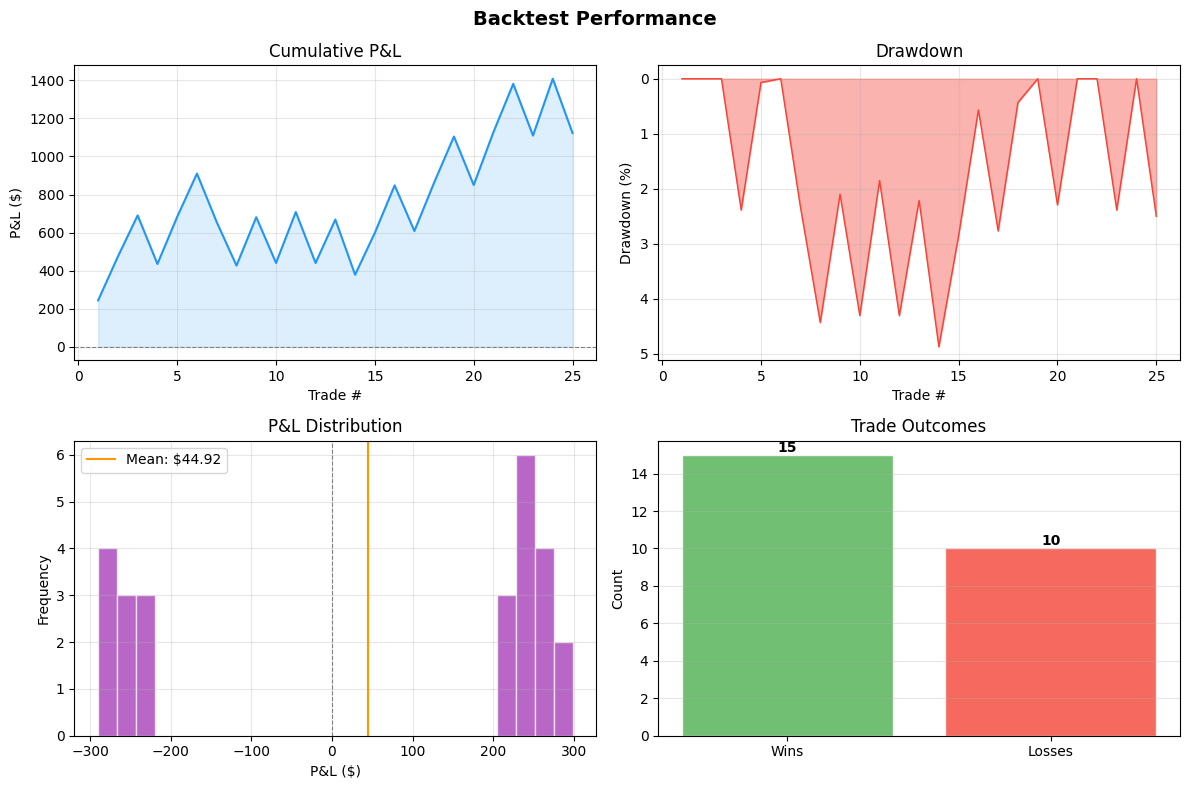

In [9]:
plot_performance(results)

## Train/Test Split: Why and How

### Why You Cannot Evaluate on Training Data

If you develop a strategy by looking at historical results and then measure performance on the **same** data, you are evaluating on your training set. This is the cardinal sin of quantitative research:

1. **Overfitting:** Your strategy learns the noise in the specific dataset, not a real signal.
2. **Inflated metrics:** Sharpe ratios, win rates, and ROI will all look better than they actually are.
3. **Deployment failure:** The strategy will underperform (or lose money) on new, unseen data.

The solution is simple: **split your data into train and test sets**, develop your strategy on the train set, and evaluate final performance ONLY on the test set.

### How to Split

For time-series data (like sports betting), you must split **chronologically** -- never randomly. Random splits leak future information into the training set.

```python
# Chronological train/test split (70/30)
split_idx = int(len(data) * 0.7)
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx:].copy()
```

If `cuic_quant.backtest.walk_forward` is available, use the built-in helper:

```python
from cuic_quant.backtest.walk_forward import train_test_split
train_data, test_data = train_test_split(data, train_pct=0.7)
```

In [ ]:
# --- Train/Test Split Demonstration ---
# Split data chronologically: first 70% for training, last 30% for testing
split_idx = int(len(data) * 0.7)
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx:].copy()

print(f"Total games:  {len(data)}")
print(f"Train set:    {len(train_data)} games ({train_data['timestamp'].iloc[0]} to {train_data['timestamp'].iloc[-1]})")
print(f"Test set:     {len(test_data)} games ({test_data['timestamp'].iloc[0]} to {test_data['timestamp'].iloc[-1]})")
print()

# Run backtest on TRAIN data (in-sample)
train_results = backtest(train_data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)
# Run backtest on TEST data (out-of-sample)
test_results = backtest(test_data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)

def quick_metrics(results_df, label):
    """Print key metrics for a results DataFrame."""
    if len(results_df) == 0:
        print(f"  {label}: No trades executed.")
        return
    wins = (results_df["outcome"] == "WIN").sum()
    n = len(results_df)
    pnl = results_df["cumulative_pnl"].iloc[-1]
    total_wagered = results_df["bet_size"].sum()
    roi = pnl / total_wagered if total_wagered > 0 else 0
    print(f"  {label}:")
    print(f"    Trades:    {n}")
    print(f"    Win Rate:  {wins/n:.1%} ({wins}W / {n - wins}L)")
    print(f"    Total PnL: ${pnl:,.2f}")
    print(f"    ROI:       {roi:.1%}")
    print()

print("=" * 50)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 50)
quick_metrics(train_results, "Train (in-sample)")
quick_metrics(test_results, "Test (out-of-sample)")

### Interpreting Train vs Test Results

**What to look for:**

- If test performance is **much worse** than train performance, your strategy is likely overfit.
- If test performance is **similar** to train performance, the strategy *may* generalize -- but with only ~7-8 test games, this is not conclusive.
- **Never tune parameters** based on test set results. If you do, the test set becomes a second training set and you need a third holdout.

**Critical caveat for this dataset:** With 25 total rows, the train set has ~17 games and the test set has ~8 games. This is **far too few** for any statistical conclusion. A single lucky/unlucky bet swings ROI by 10+ percentage points. In production, you would want at minimum 200+ games in the test set before trusting any metric.

For strategies with tunable parameters, use **walk-forward analysis** instead of a single train/test split. Walk-forward repeatedly trains on a sliding window and tests on the next window, giving you multiple out-of-sample evaluations.

## Conclusion

This notebook demonstrates the full backtesting pipeline:

1. **Data loading** from CSV (or Railway database when available)
2. **Strategy evaluation** using a pluggable strategy interface
3. **Validation** across 11 checks (schema, math, data leakage)
4. **Performance metrics** (Sharpe, Sortino, drawdown, profit factor, streaks)
5. **Visualizations** (equity curve, drawdown, PnL distribution, outcomes)

To build your own strategy, implement a function matching the interface in `docs/reference/strategy-interface.md` and pass it to `backtest()`.

For Kelly Criterion position sizing, set `position_sizing="kelly"` and return a `confidence` value (0-1) from your strategy.

For transaction cost modeling, use `cost_pct` (percentage on wins) and `cost_flat` (flat fee per trade).